
# Geo-Nexus v3.2 — P4a Maharashtra Zero-Shot Evaluation

This notebook implements **P4a / P-ZS only** from the current source-locked Geo-Nexus pipeline.

## Protocol

- Start from the completed **P3 OSCD binary checkpoint**.
- Use the compact P4 evaluation-source dataset `sumit07125/geonexus-mh-p4-eval-v3-2`.
- **No Maharashtra labels are used for model training.**
- Force the fusion gate to `optical_only`, i.e. `g = 1.0`.
- Freeze every model parameter.
- Recover the **actual P3 OSCD validation threshold from the P3 artifact**; never hard-code a guessed threshold.
- Select a separate calibrated threshold on **MH-VAL only**.
- Apply both frozen thresholds to **MH-TEST only**.
- Report threshold-free Average Precision (AP) together with Precision, Recall, F1, IoU, Accuracy, and Cohen's kappa where defined.
- Treat label `255` as **ignore**, never as no-change.

## Current verified Maharashtra scope

- MH-VAL: 30 patches = 15 Pune + 15 Satara
- MH-ADAPT: 30 patches = 15 Pune + 15 Satara (**not used in P4a**)
- MH-TEST: 110 patches = 40 Pune + 40 Satara + 30 Vidarbha
- The excluded blind/monsoon masks are not synthesized.

## Required Kaggle inputs

Attach exactly these two datasets with **Add Input**:

1. `sumit07125/geonexus-p3-oscd-artifacts`
2. `sumit07125/geonexus-mh-p4-eval-v3-2`

The notebook discovers files recursively under `/kaggle/input`; it does not depend on a fixed mount directory name.

> This notebook deliberately does **not** implement P4b few-shot training. P4b is the next experimental stage and is kept separate so P4a remains a clean zero-shot result.



## Source-lock notes

The model implementation is loaded from the exact `p3_geonexus_model.py` artifact produced by the executed P3 notebook rather than re-created in this notebook. This prevents architectural drift between P3 and P4a.

The P4 data contract follows the executed staging notebook: inputs are `[N, 2, 17, 128, 128]` int16 arrays with train-only normalization statistics, and verified masks are `uint8` with values `0..6` plus `255` ignore. P4a collapses `1..6` into binary change (`1`) only for metric computation.


In [1]:

# ============================================================
# CELL 1 — runtime, reproducibility, configuration
# ============================================================
from pathlib import Path
import os, sys, json, math, time, hashlib, shutil, importlib.util, csv, gc
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import average_precision_score, cohen_kappa_score
import matplotlib.pyplot as plt

SEED = 20260922
PATCH = 128
INPUT_CHANNELS = 17
SAR_CHANNELS = (13, 14, 15)
Q_CHANNEL = 16
IGNORE = 255
BATCH_SIZE = 8
NUM_WORKERS = 0
BOOTSTRAP_RESAMPLES = 2000
THRESHOLD_LO = 0.05
THRESHOLD_HI = 0.95
THRESHOLD_STEP = 0.01

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

RUN_DIR = Path('/kaggle/working/geonexus_p4a_mh') if Path('/kaggle/working').exists() else Path('/mnt/data/geonexus_p4a_mh_local')
RUN_DIR.mkdir(parents=True, exist_ok=True)
INPUT_ROOT = Path('/kaggle/input') if Path('/kaggle/input').exists() else None

print('=' * 78)
print('Geo-Nexus v3.2 — P4a Maharashtra Zero-Shot Evaluation')
print('=' * 78)
print('Device :', DEVICE)
if DEVICE.type == 'cuda':
    print('GPU    :', torch.cuda.get_device_name(0))
print('PyTorch:', torch.__version__)
print('Run dir:', RUN_DIR)


Geo-Nexus v3.2 — P4a Maharashtra Zero-Shot Evaluation
Device : cpu
PyTorch: 2.10.0+cpu
Run dir: /kaggle/working/geonexus_p4a_mh


In [2]:

# ============================================================
# CELL 2 — robust Kaggle artifact discovery
# ============================================================
if INPUT_ROOT is None:
    raise RuntimeError(
        'This notebook is intended for Kaggle evaluation. /kaggle/input is missing. '
        'Open the notebook on Kaggle and attach the two required datasets.'
    )

INPUT_FILES = sorted(
    [p for p in INPUT_ROOT.rglob('*') if p.is_file()],
    key=lambda p: str(p),
)


def sha256_file(path, chunk=8 * 1024 * 1024):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(chunk), b''):
            h.update(block)
    return h.hexdigest()


def find_artifact(basename, preferred_tokens=(), required=True):
    hits = [p for p in INPUT_FILES if p.name == basename]
    if not hits:
        if required:
            raise FileNotFoundError(
                f"Required P4a artifact '{basename}' was not found under /kaggle/input.\n\n"
                'Attach these datasets:\n'
                '  1) sumit07125/geonexus-p3-oscd-artifacts\n'
                '  2) sumit07125/geonexus-mh-p4-eval-v3-2'
            )
        return None

    preferred = [
        p for p in hits
        if any(token.lower() in str(p).lower() for token in preferred_tokens)
    ]
    candidates = preferred if preferred else hits

    if len(candidates) == 1:
        return candidates[0]

    hashes = {sha256_file(p) for p in candidates}
    if len(hashes) == 1:
        return sorted(candidates, key=str)[0]

    raise RuntimeError(
        f"Ambiguous non-identical copies of '{basename}' were found:\n"
        + '\n'.join(f'  - {p}' for p in candidates)
    )


P3_TOKEN = 'geonexus-p3-oscd-artifacts'
P4_TOKEN = 'geonexus-mh-p4-eval-v3-2'

MODEL_PY_SRC = find_artifact('p3_geonexus_model.py', preferred_tokens=(P3_TOKEN,))
P3_FINAL_CKPT = find_artifact('geonexus_v3_2_p3_oscd_model.pth', preferred_tokens=(P3_TOKEN,))
P3_METRICS = find_artifact('p3_oscd_test_metrics.json', preferred_tokens=(P3_TOKEN,), required=False)
P3_SWEEP = find_artifact('p3_oscd_val_threshold_sweep.json', preferred_tokens=(P3_TOKEN,), required=False)

NORM_CANDIDATES = [p for p in INPUT_FILES if p.name == 'norm_stats_trainonly.json']
if not NORM_CANDIDATES:
    raise FileNotFoundError('Required norm_stats_trainonly.json is missing from the attached inputs.')
NORM_JSON = next(
    (p for p in NORM_CANDIDATES if P4_TOKEN in str(p).lower()),
    NORM_CANDIDATES[0],
)

P4_FILES = {
    'val_x': find_artifact('p4_mh_val.npy', preferred_tokens=(P4_TOKEN,)),
    'val_y': find_artifact('p4_mh_val_labels.npy', preferred_tokens=(P4_TOKEN,)),
    'val_meta': find_artifact('p4_mh_val_manifest.json', preferred_tokens=(P4_TOKEN,)),
    'adapt_x': find_artifact('p4_mh_adapt.npy', preferred_tokens=(P4_TOKEN,)),
    'adapt_y': find_artifact('p4_mh_adapt_labels.npy', preferred_tokens=(P4_TOKEN,)),
    'adapt_meta': find_artifact('p4_mh_adapt_manifest.json', preferred_tokens=(P4_TOKEN,)),
    'test_x': find_artifact('p4_mh_test.npy', preferred_tokens=(P4_TOKEN,)),
    'test_y': find_artifact('p4_mh_test_labels.npy', preferred_tokens=(P4_TOKEN,)),
    'test_meta': find_artifact('p4_mh_test_manifest.json', preferred_tokens=(P4_TOKEN,)),
}

print('=' * 78)
print('P4a INPUT DISCOVERY GATE: PASS')
print('=' * 78)
print('P3 model source :', MODEL_PY_SRC)
print('P3 checkpoint   :', P3_FINAL_CKPT)
print('P3 metrics      :', P3_METRICS)
print('P3 sweep        :', P3_SWEEP)
print('Normalization   :', NORM_JSON)
for key, value in P4_FILES.items():
    print(f'{key:12s}: {value}')


P4a INPUT DISCOVERY GATE: PASS
P3 model source : /kaggle/input/datasets/sumit07125/geonexus-p3-oscd-artifacts/p3_geonexus_model.py
P3 checkpoint   : /kaggle/input/datasets/sumit07125/geonexus-p3-oscd-artifacts/geonexus_v3_2_p3_oscd_model.pth
P3 metrics      : /kaggle/input/datasets/sumit07125/geonexus-p3-oscd-artifacts/p3_oscd_test_metrics.json
P3 sweep        : /kaggle/input/datasets/sumit07125/geonexus-p3-oscd-artifacts/p3_oscd_val_threshold_sweep.json
Normalization   : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/norm_stats_trainonly.json
val_x       : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_val.npy
val_y       : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_val_labels.npy
val_meta    : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_val_manifest.json
adapt_x     : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-2/p4_mh_adapt.npy
adapt_y     : /kaggle/input/datasets/sumit07125/geonexus-mh-p4-eval-v3-

In [3]:

# ============================================================
# CELL 3 — exact tensor / label / normalization gates
# ============================================================

def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def check_array(path, expected_n):
    arr = np.load(path, mmap_mode='r')
    expected = (expected_n, 2, INPUT_CHANNELS, PATCH, PATCH)
    if arr.dtype != np.int16:
        raise TypeError(f'{path.name}: expected int16, got {arr.dtype}')
    if tuple(arr.shape) != expected:
        raise ValueError(f'{path.name}: expected {expected}, got {arr.shape}')
    return arr


def check_labels(path, expected_n):
    y = np.load(path, mmap_mode='r')
    expected = (expected_n, PATCH, PATCH)
    if y.dtype != np.uint8:
        raise TypeError(f'{path.name}: expected uint8, got {y.dtype}')
    if tuple(y.shape) != expected:
        raise ValueError(f'{path.name}: expected {expected}, got {y.shape}')
    vals = set(np.unique(y).tolist())
    allowed = set(range(7)) | {IGNORE}
    if not vals.issubset(allowed):
        raise ValueError(f'{path.name}: unexpected label IDs {sorted(vals)}')
    return y

val_x = check_array(P4_FILES['val_x'], 30)
val_y = check_labels(P4_FILES['val_y'], 30)
adapt_x = check_array(P4_FILES['adapt_x'], 30)
adapt_y = check_labels(P4_FILES['adapt_y'], 30)
test_x = check_array(P4_FILES['test_x'], 110)
test_y = check_labels(P4_FILES['test_y'], 110)

val_meta = load_json(P4_FILES['val_meta'])
adapt_meta = load_json(P4_FILES['adapt_meta'])
test_meta = load_json(P4_FILES['test_meta'])


def canonical_zone(record):
    explicit = str(record.get('source_zone', record.get('zone', '')) or '').strip().lower()
    stem = str(record.get('stem', '')).strip().lower()
    if explicit:
        zone = explicit
    else:
        zone = stem.split('_', 1)[0] if '_' in stem else ''
    if zone not in {'pune', 'satara', 'vidarbha'}:
        raise ValueError(f'Cannot determine canonical zone for manifest entry: {record}')
    if stem and not stem.startswith(zone + '_'):
        raise ValueError(f'Zone/stem disagreement: zone={zone!r}, stem={stem!r}')
    return zone


def validate_manifest(name, meta, expected_n, expected_zone_counts):
    if len(meta) != expected_n:
        raise ValueError(f'{name}: manifest count {len(meta)} != {expected_n}')
    stems = [str(m.get('stem', '')).strip() for m in meta]
    if any(not s for s in stems):
        raise ValueError(f'{name}: every manifest row must contain stem')
    if len(stems) != len(set(stems)):
        raise RuntimeError(f'{name}: duplicate stems found')
    zones = [canonical_zone(m) for m in meta]
    counts = dict(sorted({z: zones.count(z) for z in set(zones)}.items()))
    if counts != expected_zone_counts:
        raise ValueError(f'{name}: zone counts {counts} != {expected_zone_counts}')
    return zones

val_zones = validate_manifest('MH-VAL', val_meta, 30, {'pune': 15, 'satara': 15})
adapt_zones = validate_manifest('MH-ADAPT', adapt_meta, 30, {'pune': 15, 'satara': 15})
test_zones = validate_manifest('MH-TEST', test_meta, 110, {'pune': 40, 'satara': 40, 'vidarbha': 30})

all_stems = [m['stem'] for m in val_meta + adapt_meta + test_meta]
if len(all_stems) != len(set(all_stems)):
    raise RuntimeError('P4 split stems overlap; validation/adaptation/test are not patch-disjoint.')

stats = load_json(NORM_JSON)
required_stats = {'mean', 'std', 'array_scale', 'sar_channels', 'sar_extra_scale'}
missing_stats = required_stats.difference(stats)
if missing_stats:
    raise KeyError(f'Normalization file missing keys: {sorted(missing_stats)}')

MU = np.asarray(stats['mean'], np.float32).reshape(INPUT_CHANNELS, 1, 1)
SD = np.asarray(stats['std'], np.float32).reshape(INPUT_CHANNELS, 1, 1)
ARRAY_SCALE = float(stats['array_scale'])
STAT_SAR = tuple(int(v) for v in stats['sar_channels'])
SAR_EXTRA_SCALE = float(stats['sar_extra_scale'])

if not np.all(np.isfinite(MU)) or not np.all(np.isfinite(SD)):
    raise ValueError('Normalization mean/std contains non-finite values.')
if ARRAY_SCALE != 10000.0:
    raise ValueError(f'Expected array_scale=10000.0, got {ARRAY_SCALE}')
if STAT_SAR != SAR_CHANNELS:
    raise ValueError(f'Expected SAR channels {SAR_CHANNELS}, got {STAT_SAR}')
if SAR_EXTRA_SCALE != 100.0:
    raise ValueError(f'Expected SAR extra scale=100.0, got {SAR_EXTRA_SCALE}')
if not (np.allclose(MU[11:13], 0) and np.allclose(SD[11:13], 1)):
    raise ValueError('NDVI/NDBI identity-normalization contract failed.')
if not (np.allclose(MU[16], 0) and np.allclose(SD[16], 1)):
    raise ValueError('q-channel identity-normalization contract failed.')

print('=' * 78)
print('P4a DATA CONTRACT GATE: PASS')
print('=' * 78)
print('MH-VAL   :', tuple(val_x.shape))
print('MH-ADAPT :', tuple(adapt_x.shape), '(not used in P4a)')
print('MH-TEST  :', tuple(test_x.shape))
print('Labels   : 0..6 + 255 ignore')
print('Zones    :', {
    'MH-VAL': dict(sorted({z: val_zones.count(z) for z in set(val_zones)}.items())),
    'MH-ADAPT': dict(sorted({z: adapt_zones.count(z) for z in set(adapt_zones)}.items())),
    'MH-TEST': dict(sorted({z: test_zones.count(z) for z in set(test_zones)}.items())),
})


P4a DATA CONTRACT GATE: PASS
MH-VAL   : (30, 2, 17, 128, 128)
MH-ADAPT : (30, 2, 17, 128, 128) (not used in P4a)
MH-TEST  : (110, 2, 17, 128, 128)
Labels   : 0..6 + 255 ignore
Zones    : {'MH-VAL': {'pune': 15, 'satara': 15}, 'MH-ADAPT': {'pune': 15, 'satara': 15}, 'MH-TEST': {'pune': 40, 'satara': 40, 'vidarbha': 30}}


In [4]:

# ============================================================
# CELL 4 — load exact P3 model implementation + recover threshold
# ============================================================
MODEL_PY = RUN_DIR / 'p3_geonexus_model.py'
shutil.copy2(MODEL_PY_SRC, MODEL_PY)
source_text = MODEL_PY.read_text(encoding='utf-8')
compile(source_text, str(MODEL_PY), 'exec')

spec = importlib.util.spec_from_file_location('p3_geonexus_model', MODEL_PY)
if spec is None or spec.loader is None:
    raise ImportError('Could not construct import specification for p3_geonexus_model.py')
p3 = importlib.util.module_from_spec(spec)
spec.loader.exec_module(p3)
if not hasattr(p3, 'GeoNexusCD'):
    raise AttributeError('p3_geonexus_model.py does not expose GeoNexusCD')
if not hasattr(p3.GeoNexusCD, 'set_mode'):
    raise AttributeError('GeoNexusCD.set_mode is missing; P4a requires optical_only mode control')

raw_ckpt = torch.load(P3_FINAL_CKPT, map_location='cpu', weights_only=False)
state = raw_ckpt.get('model', raw_ckpt) if isinstance(raw_ckpt, dict) else raw_ckpt
if not isinstance(state, dict):
    raise TypeError('P3 checkpoint does not contain a state_dict-like dictionary')

# Recover the threshold from the actual P3 artifact. Never guess it here.
p3_threshold = None
p3_best_epoch = None
p3_best_val_f1 = None
if isinstance(raw_ckpt, dict):
    if raw_ckpt.get('best_val_threshold') is not None:
        p3_threshold = float(raw_ckpt['best_val_threshold'])
    if raw_ckpt.get('best_epoch') is not None:
        p3_best_epoch = int(raw_ckpt['best_epoch'])
    if raw_ckpt.get('best_val_f1') is not None:
        p3_best_val_f1 = float(raw_ckpt['best_val_f1'])

if p3_threshold is None and P3_METRICS is not None:
    metrics = load_json(P3_METRICS)
    if metrics.get('best_val_threshold') is not None:
        p3_threshold = float(metrics['best_val_threshold'])

if p3_threshold is None and P3_SWEEP is not None:
    sweep = load_json(P3_SWEEP)
    candidates = sweep.get('rows', sweep if isinstance(sweep, list) else None)
    if isinstance(candidates, list) and candidates:
        usable = []
        for row in candidates:
            if isinstance(row, dict) and row.get('threshold') is not None and row.get('f1') is not None:
                usable.append((float(row['f1']), float(row['threshold'])))
        if usable:
            p3_threshold = max(usable, key=lambda z: (z[0], -abs(z[1] - 0.5)))[1]

if p3_threshold is None:
    raise RuntimeError(
        'Could not recover the P3 OSCD validation threshold from the attached P3 artifacts. '
        'Do not hard-code a threshold; attach the complete geonexus-p3-oscd-artifacts dataset.'
    )

if not (0.0 < p3_threshold < 1.0):
    raise ValueError(f'Recovered invalid P3 threshold: {p3_threshold}')

model = p3.GeoNexusCD(decoder='lka').to(DEVICE)

try:
    model.load_state_dict(state, strict=True)
except RuntimeError as first_error:
    # Support a checkpoint saved under DataParallel only when every key has the same prefix.
    if state and all(str(k).startswith('module.') for k in state):
        stripped = {str(k)[7:]: v for k, v in state.items()}
        model.load_state_dict(stripped, strict=True)
        print('✓ stripped uniform DataParallel "module." prefix')
    else:
        raise RuntimeError(f'Exact P3 checkpoint transfer failed: {first_error}') from first_error

print('=' * 78)
print('P3 CHECKPOINT GATE: PASS')
print('=' * 78)
print('P3 best epoch      :', p3_best_epoch)
print('P3 best OSCD F1    :', p3_best_val_f1)
print('P3 locked threshold:', p3_threshold)
print('P3 parameters      :', sum(p.numel() for p in model.parameters()))


P3 CHECKPOINT GATE: PASS
P3 best epoch      : 10
P3 best OSCD F1    : 0.48309189690288096
P3 locked threshold: 0.52
P3 parameters      : 25234955


In [5]:

# ============================================================
# CELL 5 — memory-mapped P4 dataset + exact normalization
# ============================================================
class P4MHDataset(Dataset):
    def __init__(self, x_path, y_path, meta_path, split_name):
        self.x = np.load(x_path, mmap_mode='r')
        self.y = np.load(y_path, mmap_mode='r')
        self.meta = load_json(meta_path)
        self.split_name = split_name
        if self.x.shape[0] != len(self.y) or self.x.shape[0] != len(self.meta):
            raise ValueError(f'{split_name}: array/label/manifest counts disagree')

    def __len__(self):
        return int(self.x.shape[0])

    def __getitem__(self, idx):
        raw = np.asarray(self.x[idx], dtype=np.int16)
        label = np.asarray(self.y[idx], dtype=np.uint8)
        x = raw.astype(np.float32) / ARRAY_SCALE
        x[:, SAR_CHANNELS] *= SAR_EXTRA_SCALE
        x = (x - MU[None, :, :, :]) / (SD[None, :, :, :] + 1e-6)
        q = raw[:, Q_CHANNEL].astype(np.float32) / ARRAY_SCALE
        if q.min() < -1e-6 or q.max() > 1.00001:
            raise ValueError(f'{self.split_name}[{idx}]: q outside [0,1]')
        # Binary metric target: annotation IDs 1..6 are change; 0 is no-change; 255 is ignore.
        y_binary = np.zeros_like(label, dtype=np.uint8)
        valid = label != IGNORE
        y_binary[valid] = (label[valid] > 0).astype(np.uint8)
        return {
            'x1': torch.from_numpy(np.ascontiguousarray(x[0])),
            'x2': torch.from_numpy(np.ascontiguousarray(x[1])),
            'y': torch.from_numpy(y_binary.copy()),
            'y_raw': torch.from_numpy(label.copy()),
            'q_mean': float(q.mean()),
            'stem': str(self.meta[idx]['stem']),
            'zone': canonical_zone(self.meta[idx]),
        }

val_ds = P4MHDataset(P4_FILES['val_x'], P4_FILES['val_y'], P4_FILES['val_meta'], 'MH-VAL')
adapt_ds = P4MHDataset(P4_FILES['adapt_x'], P4_FILES['adapt_y'], P4_FILES['adapt_meta'], 'MH-ADAPT')
test_ds = P4MHDataset(P4_FILES['test_x'], P4_FILES['test_y'], P4_FILES['test_meta'], 'MH-TEST')

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'))

val_labels_binary = [val_ds[i]['y'].numpy() for i in range(len(val_ds))]
test_labels_binary = [test_ds[i]['y'].numpy() for i in range(len(test_ds))]

sample = val_ds[0]
assert sample['x1'].shape == (INPUT_CHANNELS, PATCH, PATCH)
assert sample['x2'].shape == (INPUT_CHANNELS, PATCH, PATCH)
assert sample['y'].shape == (PATCH, PATCH)

print('=' * 78)
print('P4a DATALOADER GATE: PASS')
print('=' * 78)
print('VAL item:', sample['stem'])
print('x1/x2   :', tuple(sample['x1'].shape), tuple(sample['x2'].shape))
print('q mean  :', sample['q_mean'])


P4a DATALOADER GATE: PASS
VAL item: pune_1024_1472
x1/x2   : (17, 128, 128) (17, 128, 128)
q mean  : 1.0


In [6]:

# ============================================================
# CELL 6 — P4a optical-only freeze gate + inference utilities
# ============================================================
@torch.no_grad()
def predict_probabilities(model_obj, loader):
    model_obj.eval()
    probs = []
    stems = []
    zones = []
    for batch in loader:
        x1 = batch['x1'].to(DEVICE, non_blocking=True)
        x2 = batch['x2'].to(DEVICE, non_blocking=True)
        out = model_obj(x1, x2)
        logits = out['logits']
        if logits.ndim != 4 or logits.shape[1] != 1 or logits.shape[-2:] != (PATCH, PATCH):
            raise ValueError(f'Unexpected P3 output logits shape: {tuple(logits.shape)}')
        probs.append(torch.sigmoid(logits[:, 0]).float().cpu().numpy())
        stems.extend([str(s) for s in batch['stem']])
        zones.extend([str(z) for z in batch['zone']])
    return np.concatenate(probs, axis=0), stems, zones


zs_model = p3.GeoNexusCD(decoder='lka').to(DEVICE)
try:
    zs_model.load_state_dict(state, strict=True)
except RuntimeError:
    if state and all(str(k).startswith('module.') for k in state):
        zs_model.load_state_dict({str(k)[7:]: v for k, v in state.items()}, strict=True)
    else:
        raise
zs_model.set_mode('optical_only')
for param in zs_model.parameters():
    param.requires_grad_(False)
zs_model.eval()

probe_batch = next(iter(val_loader))
with torch.no_grad():
    probe_out = zs_model(
        probe_batch['x1'].to(DEVICE),
        probe_batch['x2'].to(DEVICE),
    )

if not isinstance(probe_out, dict) or 'logits' not in probe_out or 'gates' not in probe_out:
    raise RuntimeError('P3 forward output does not match the audited GeoNexusCD contract.')

gate_means = [float(g.mean().detach().cpu()) for g in probe_out['gates']]
if not gate_means or not all(abs(v - 1.0) <= 1e-6 for v in gate_means):
    raise RuntimeError(f'P4a optical-only gate check failed: {gate_means}')
if any(param.requires_grad for param in zs_model.parameters()):
    raise RuntimeError('P4a freeze check failed: at least one model parameter requires gradients.')

# One finite inference smoke before the full pass.
if not torch.isfinite(probe_out['logits']).all():
    raise FloatingPointError('P4a probe logits contain non-finite values.')

print('P4a gate=1.0 PASS:', gate_means)
print('P4a all-parameters-frozen PASS')

val_prob_zs, val_stems, val_pred_zones = predict_probabilities(zs_model, val_loader)
test_prob_zs, test_stems, test_pred_zones = predict_probabilities(zs_model, test_loader)

if val_stems != [m['stem'] for m in val_meta]:
    raise RuntimeError('MH-VAL DataLoader order does not match the verified manifest order.')
if test_stems != [m['stem'] for m in test_meta]:
    raise RuntimeError('MH-TEST DataLoader order does not match the verified manifest order.')

print('P4a zero-shot inference PASS')
print('VAL probability array :', val_prob_zs.shape)
print('TEST probability array:', test_prob_zs.shape)


P4a gate=1.0 PASS: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
P4a all-parameters-frozen PASS
P4a zero-shot inference PASS
VAL probability array : (30, 128, 128)
TEST probability array: (110, 128, 128)


In [7]:

# ============================================================
# CELL 7 — threshold calibration + metrics with 255 masking
# ============================================================
def counts_for_patch(prob, y_binary, threshold):
    # Labels already map 255 -> ignored pixels in the dataset, but infer validity
    # from the original mask separately to guarantee 255 never becomes negative class.
    # Recover valid mask from binary target plus original labels in the caller instead.
    pred = prob >= threshold
    gt = y_binary.astype(bool)
    return (
        int(np.logical_and(pred, gt).sum()),
        int(np.logical_and(pred, ~gt).sum()),
        int(np.logical_and(~pred, gt).sum()),
        int(np.logical_and(~pred, ~gt).sum()),
    )


def build_binary_and_valid(raw_labels):
    raw = np.asarray(raw_labels, dtype=np.uint8)
    valid = raw != IGNORE
    binary = np.zeros(raw.shape, dtype=np.uint8)
    binary[valid] = (raw[valid] > 0).astype(np.uint8)
    return binary, valid


# Use the original raw labels for the ignore mask. Do not use y_binary alone.
val_binary_valid = [build_binary_and_valid(val_y[i]) for i in range(len(val_y))]
test_binary_valid = [build_binary_and_valid(test_y[i]) for i in range(len(test_y))]


def threshold_f1(probs, binary_valid_pairs, threshold):
    tp = fp = fn = 0
    for p, (y, valid) in zip(probs, binary_valid_pairs):
        pp = (p >= threshold) & valid
        yy = (y == 1) & valid
        tp += int(np.logical_and(pp, yy).sum())
        fp += int(np.logical_and(pp, ~yy & valid).sum())
        fn += int(np.logical_and(~pp & valid, yy).sum())
    return float(2 * tp / max(2 * tp + fp + fn, 1))


def choose_threshold(probs, binary_valid_pairs, lo=THRESHOLD_LO, hi=THRESHOLD_HI, step=THRESHOLD_STEP):
    rows = []
    best = None
    for threshold in np.round(np.arange(lo, hi + 1e-9, step), 2):
        f1 = threshold_f1(probs, binary_valid_pairs, float(threshold))
        row = {'threshold': float(threshold), 'f1': float(f1)}
        rows.append(row)
        candidate = (f1, -abs(float(threshold) - 0.5), -float(threshold))
        if best is None or candidate > best[0]:
            best = (candidate, row)
    assert best is not None
    return float(best[1]['threshold']), float(best[1]['f1']), rows


def evaluate_prediction_set(probs, raw_labels, threshold, bootstrap=BOOTSTRAP_RESAMPLES, seed=SEED):
    counts = []
    flat_prob = []
    flat_y = []
    for p, raw in zip(probs, raw_labels):
        y, valid = build_binary_and_valid(raw)
        pred = (p >= threshold) & valid
        gt = (y == 1) & valid
        tp = int(np.logical_and(pred, gt).sum())
        fp = int(np.logical_and(pred, ~gt & valid).sum())
        fn = int(np.logical_and(~pred & valid, gt).sum())
        tn = int(np.logical_and(~pred & valid, ~gt & valid).sum())
        counts.append((tp, fp, fn, tn))
        flat_prob.append(p[valid])
        flat_y.append(y[valid])

    counts = np.asarray(counts, dtype=np.int64)
    tp, fp, fn, tn = counts.sum(axis=0).tolist()
    precision = float(tp / max(tp + fp, 1))
    recall = float(tp / max(tp + fn, 1))
    f1 = float(2 * tp / max(2 * tp + fp + fn, 1))
    iou = float(tp / max(tp + fp + fn, 1))
    accuracy = float((tp + tn) / max(tp + fp + fn + tn, 1))

    vf = np.concatenate(flat_prob) if flat_prob else np.empty(0, dtype=np.float32)
    vy = np.concatenate(flat_y) if flat_y else np.empty(0, dtype=np.uint8)
    ap = float(average_precision_score(vy, vf)) if vy.size and np.unique(vy).size > 1 else float('nan')
    kappa = float(cohen_kappa_score(vy, (vf >= threshold).astype(np.uint8))) if vy.size and np.unique(vy).size > 1 else float('nan')

    patch_f1 = []
    for c in counts:
        ptp, pfp, pfn = c[:3]
        patch_f1.append(float(2 * ptp / max(2 * ptp + pfp + pfn, 1)))

    rng = np.random.default_rng(seed)
    boot = np.empty(bootstrap, dtype=np.float64)
    n = len(counts)
    for i in range(bootstrap):
        idx = rng.integers(0, n, size=n)
        sample = counts[idx]
        btp = int(sample[:, 0].sum())
        bfp = int(sample[:, 1].sum())
        bfn = int(sample[:, 2].sum())
        boot[i] = 2 * btp / max(2 * btp + bfp + bfn, 1)
    ci = np.percentile(boot, [2.5, 97.5])

    return {
        'threshold': float(threshold),
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'iou': iou,
        'accuracy': accuracy,
        'average_precision': ap,
        'kappa': kappa,
        'f1_per_patch_mean': float(np.mean(patch_f1)),
        'f1_ci95': [float(ci[0]), float(ci[1])],
        'n_patches': int(n),
        'n_valid_pixels': int(vf.size),
        'tp': int(tp), 'fp': int(fp), 'fn': int(fn), 'tn': int(tn),
    }


mh_val_threshold, mh_val_f1, val_sweep = choose_threshold(
    val_prob_zs,
    val_binary_valid,
)

zs_strict = evaluate_prediction_set(
    test_prob_zs,
    test_y,
    p3_threshold,
    seed=SEED,
)
zs_calibrated = evaluate_prediction_set(
    test_prob_zs,
    test_y,
    mh_val_threshold,
    seed=SEED + 1,
)


print('=' * 78)
print('P4a ZERO-SHOT RESULTS')
print('=' * 78)
print(f'ZS-strict     threshold={p3_threshold:.2f} F1={zs_strict["f1"]:.6f} IoU={zs_strict["iou"]:.6f}')
print(f'ZS-calibrated threshold={mh_val_threshold:.2f} F1={zs_calibrated["f1"]:.6f} IoU={zs_calibrated["iou"]:.6f}')
print(f'MH-VAL        threshold={mh_val_threshold:.2f} F1={mh_val_f1:.6f}')
print(f'P4a TEST AP (strict)={zs_strict["average_precision"]:.6f}')


P4a ZERO-SHOT RESULTS
ZS-strict     threshold=0.52 F1=0.058592 IoU=0.030180
ZS-calibrated threshold=0.05 F1=0.128768 IoU=0.068815
MH-VAL        threshold=0.05 F1=0.182380
P4a TEST AP (strict)=0.453977


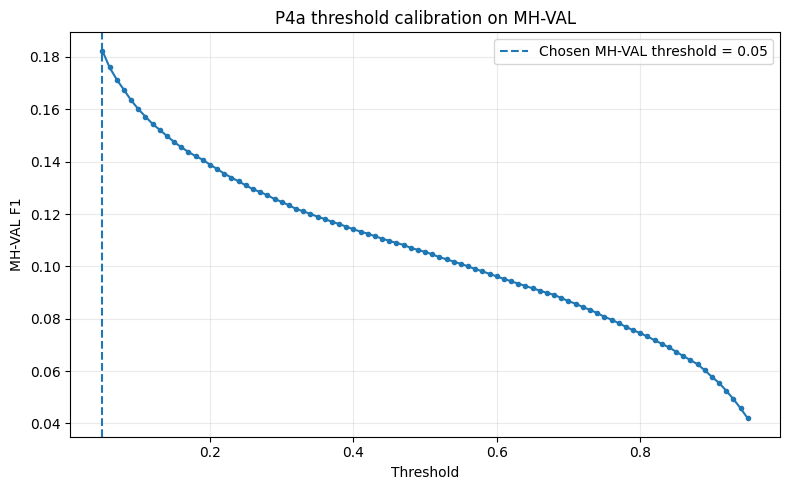

P4a PER-ZONE EVALUATION: PASS
P4a_ZS_strict            pune      n=40 F1=0.005838 IoU=0.002928 AP=0.335178
P4a_ZS_calibrated        pune      n=40 F1=0.014998 IoU=0.007555 AP=0.335178
P4a_ZS_strict            satara    n=40 F1=0.041041 IoU=0.020950 AP=0.410356
P4a_ZS_calibrated        satara    n=40 F1=0.134473 IoU=0.072083 AP=0.410356
P4a_ZS_strict            vidarbha  n=30 F1=0.125600 IoU=0.067008 AP=0.620786
P4a_ZS_calibrated        vidarbha  n=30 F1=0.225584 IoU=0.127131 AP=0.620786


In [8]:

# ============================================================
# CELL 8 — per-zone P4a evaluation and threshold sweep
# ============================================================
def evaluate_zone_rows(probs, raw_labels, meta, thresholds):
    rows = []
    for zone in ('pune', 'satara', 'vidarbha'):
        idx = [i for i, m in enumerate(meta) if canonical_zone(m) == zone]
        if not idx:
            continue
        sub_probs = [probs[i] for i in idx]
        sub_labels = [raw_labels[i] for i in idx]
        for label, threshold in thresholds:
            m = evaluate_prediction_set(
                sub_probs,
                sub_labels,
                threshold,
                bootstrap=min(1000, BOOTSTRAP_RESAMPLES),
                seed=SEED + len(zone) + int(round(threshold * 100)),
            )
            rows.append({
                'protocol': label,
                'zone': zone,
                'n_patches': len(idx),
                'threshold': float(threshold),
                'precision': m['precision'],
                'recall': m['recall'],
                'f1': m['f1'],
                'iou': m['iou'],
                'accuracy': m['accuracy'],
                'average_precision': m['average_precision'],
                'kappa': m['kappa'],
                'f1_ci95_low': m['f1_ci95'][0],
                'f1_ci95_high': m['f1_ci95'][1],
            })
    return rows

zone_rows = evaluate_zone_rows(
    test_prob_zs,
    test_y,
    test_meta,
    [('P4a_ZS_strict', p3_threshold), ('P4a_ZS_calibrated', mh_val_threshold)],
)

RUN_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_JSON = RUN_DIR / 'p4a_mh_val_threshold_sweep.json'
SWEEP_JSON.write_text(json.dumps(val_sweep, indent=2), encoding='utf-8')

ZONE_CSV = RUN_DIR / 'p4a_mh_results_per_zone.csv'
with ZONE_CSV.open('w', newline='', encoding='utf-8') as f:
    fields = [
        'protocol','zone','n_patches','threshold','precision','recall','f1','iou',
        'accuracy','average_precision','kappa','f1_ci95_low','f1_ci95_high'
    ]
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerows(zone_rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot([r['threshold'] for r in val_sweep], [r['f1'] for r in val_sweep], marker='o', markersize=3)
ax.axvline(mh_val_threshold, linestyle='--', linewidth=1.5, label=f'Chosen MH-VAL threshold = {mh_val_threshold:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('MH-VAL F1')
ax.set_title('P4a threshold calibration on MH-VAL')
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
THRESHOLD_FIG = RUN_DIR / 'p4a_mh_val_threshold_sweep.png'
fig.savefig(THRESHOLD_FIG, dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

print('=' * 78)
print('P4a PER-ZONE EVALUATION: PASS')
print('=' * 78)
for row in zone_rows:
    print(
        f"{row['protocol']:24s} {row['zone']:9s} "
        f"n={row['n_patches']:2d} F1={row['f1']:.6f} IoU={row['iou']:.6f} AP={row['average_precision']:.6f}"
    )


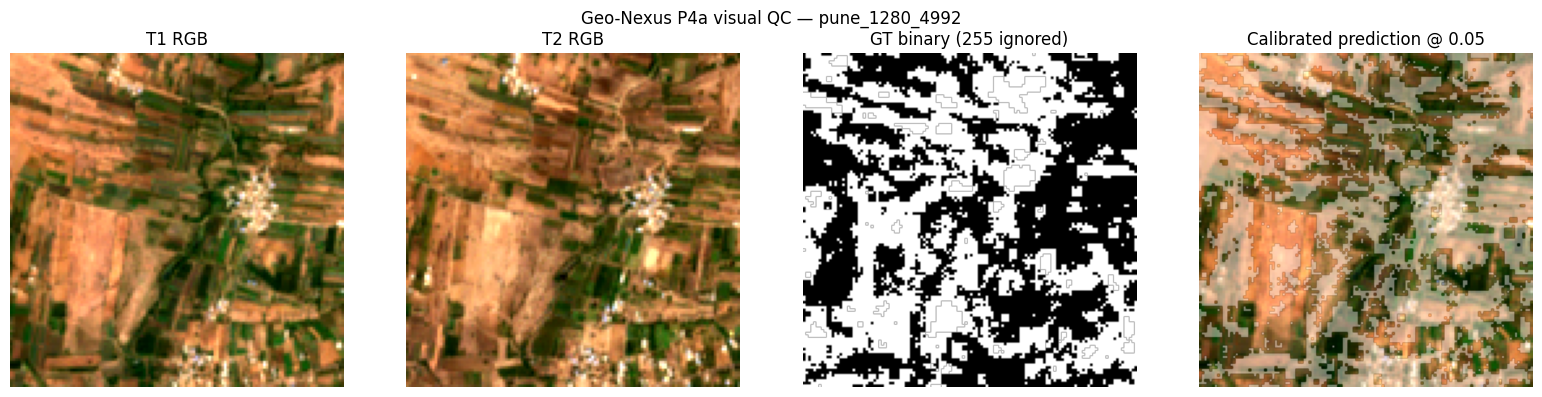

P4a ARTIFACT WRITING: PASS
Results : /kaggle/working/geonexus_p4a_mh/p4a_mh_results.json
Summary : /kaggle/working/geonexus_p4a_mh/p4a_mh_results_summary.csv
QC plot : /kaggle/working/geonexus_p4a_mh/p4a_visual_qc.png


In [9]:

# ============================================================
# CELL 9 — result artifacts + simple visual QC
# ============================================================
RESULTS = {
    'stage': 'P4a_MH_ZERO_SHOT_BINARY',
    'revision': 'p4a-v3.2-source-locked-2026-09-22',
    'p4_input_dataset': 'sumit07125/geonexus-mh-p4-eval-v3-2',
    'p3_input_dataset': 'sumit07125/geonexus-p3-oscd-artifacts',
    'test_scope': 'verified_partial_110',
    'test_count': 110,
    'test_zone_counts': {'pune': 40, 'satara': 40, 'vidarbha': 30},
    'p3_threshold': float(p3_threshold),
    'mh_val_threshold': float(mh_val_threshold),
    'mh_val_f1_at_selected_threshold': float(mh_val_f1),
    'zs_strict': zs_strict,
    'zs_calibrated': zs_calibrated,
    'label_rule': '0=no change; 1..6=change; 255=ignore',
    'mh_adapt_used_in_p4a': False,
    'gate_mode': 'optical_only',
    'gate_value': 1.0,
    'all_parameters_frozen': True,
}

RESULTS_JSON = RUN_DIR / 'p4a_mh_results.json'
RESULTS_JSON.write_text(json.dumps(RESULTS, indent=2, allow_nan=True), encoding='utf-8')

SUMMARY_CSV = RUN_DIR / 'p4a_mh_results_summary.csv'
with SUMMARY_CSV.open('w', newline='', encoding='utf-8') as f:
    fields = ['protocol','threshold_source','threshold','precision','recall','f1','iou','accuracy','average_precision','kappa','f1_ci95_low','f1_ci95_high']
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerow({
        'protocol': 'P4a_ZS_strict',
        'threshold_source': 'P3_OSCD_val',
        'threshold': p3_threshold,
        'precision': zs_strict['precision'], 'recall': zs_strict['recall'], 'f1': zs_strict['f1'],
        'iou': zs_strict['iou'], 'accuracy': zs_strict['accuracy'],
        'average_precision': zs_strict['average_precision'], 'kappa': zs_strict['kappa'],
        'f1_ci95_low': zs_strict['f1_ci95'][0], 'f1_ci95_high': zs_strict['f1_ci95'][1],
    })
    writer.writerow({
        'protocol': 'P4a_ZS_calibrated',
        'threshold_source': 'MH_VAL',
        'threshold': mh_val_threshold,
        'precision': zs_calibrated['precision'], 'recall': zs_calibrated['recall'], 'f1': zs_calibrated['f1'],
        'iou': zs_calibrated['iou'], 'accuracy': zs_calibrated['accuracy'],
        'average_precision': zs_calibrated['average_precision'], 'kappa': zs_calibrated['kappa'],
        'f1_ci95_low': zs_calibrated['f1_ci95'][0], 'f1_ci95_high': zs_calibrated['f1_ci95'][1],
    })

np.save(RUN_DIR / 'p4a_mh_test_probabilities.npy', test_prob_zs.astype(np.float32))
np.save(RUN_DIR / 'p4a_mh_test_pred_strict.npy', (test_prob_zs >= p3_threshold).astype(np.uint8))
np.save(RUN_DIR / 'p4a_mh_test_pred_calibrated.npy', (test_prob_zs >= mh_val_threshold).astype(np.uint8))

# Visual QC: T1 RGB, T2 RGB, binary GT, calibrated prediction.
qc_idx = min(3, len(test_ds) - 1)
raw_patch = np.asarray(test_x[qc_idx], dtype=np.int16).astype(np.float32) / ARRAY_SCALE
rgb1 = np.stack([raw_patch[0, 2], raw_patch[0, 1], raw_patch[0, 0]], axis=-1)
rgb2 = np.stack([raw_patch[1, 2], raw_patch[1, 1], raw_patch[1, 0]], axis=-1)

def stretch_rgb(rgb):
    lo = np.percentile(rgb, 2)
    hi = np.percentile(rgb, 98)
    return np.clip((rgb - lo) / max(hi - lo, 1e-6), 0, 1)

gt_bin, valid = build_binary_and_valid(test_y[qc_idx])
pred_bin = (test_prob_zs[qc_idx] >= mh_val_threshold)
pred_bin = pred_bin & valid

gt_display = np.ma.masked_where(~valid, gt_bin)
pred_display = np.ma.masked_where(~valid, pred_bin)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(stretch_rgb(rgb1)); axes[0].set_title('T1 RGB')
axes[1].imshow(stretch_rgb(rgb2)); axes[1].set_title('T2 RGB')
axes[2].imshow(gt_display, cmap='gray', vmin=0, vmax=1); axes[2].set_title('GT binary (255 ignored)')
axes[3].imshow(stretch_rgb(rgb1)); axes[3].imshow(pred_display, cmap='Reds', alpha=0.45, vmin=0, vmax=1); axes[3].set_title(f'Calibrated prediction @ {mh_val_threshold:.2f}')
for ax in axes: ax.axis('off')
fig.suptitle(f'Geo-Nexus P4a visual QC — {test_meta[qc_idx]["stem"]}')
fig.tight_layout()
QC_FIG = RUN_DIR / 'p4a_visual_qc.png'
fig.savefig(QC_FIG, dpi=160, bbox_inches='tight')
plt.show()
plt.close(fig)

print('=' * 78)
print('P4a ARTIFACT WRITING: PASS')
print('Results :', RESULTS_JSON)
print('Summary :', SUMMARY_CSV)
print('QC plot :', QC_FIG)


In [10]:

# ============================================================
# CELL 10 — final self-test and SHA256 manifest
# ============================================================
EXPECTED_OUTPUTS = {
    'p4a_mh_results.json',
    'p4a_mh_results_summary.csv',
    'p4a_mh_results_per_zone.csv',
    'p4a_mh_val_threshold_sweep.json',
    'p4a_mh_val_threshold_sweep.png',
    'p4a_mh_test_probabilities.npy',
    'p4a_mh_test_pred_strict.npy',
    'p4a_mh_test_pred_calibrated.npy',
    'p4a_visual_qc.png',
}

missing = sorted(name for name in EXPECTED_OUTPUTS if not (RUN_DIR / name).is_file())
if missing:
    raise RuntimeError(f'P4a final artifacts missing: {missing}')

prob = np.load(RUN_DIR / 'p4a_mh_test_probabilities.npy', mmap_mode='r')
pred_strict = np.load(RUN_DIR / 'p4a_mh_test_pred_strict.npy', mmap_mode='r')
pred_cal = np.load(RUN_DIR / 'p4a_mh_test_pred_calibrated.npy', mmap_mode='r')
if tuple(prob.shape) != (110, PATCH, PATCH):
    raise ValueError(f'Probability artifact shape mismatch: {prob.shape}')
if tuple(pred_strict.shape) != (110, PATCH, PATCH) or tuple(pred_cal.shape) != (110, PATCH, PATCH):
    raise ValueError('Prediction artifact shape mismatch.')
if not np.isfinite(prob).all():
    raise FloatingPointError('Saved P4a probabilities contain non-finite values.')
if not set(np.unique(pred_strict).tolist()).issubset({0, 1}):
    raise ValueError('Strict predictions are not binary.')
if not set(np.unique(pred_cal).tolist()).issubset({0, 1}):
    raise ValueError('Calibrated predictions are not binary.')

# Confirm exact manifest order was preserved.
assert test_stems == [m['stem'] for m in test_meta]

# Final local checksum manifest.
def file_sha(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b''):
            h.update(block)
    return h.hexdigest()

release_files = sorted(
    p for p in RUN_DIR.iterdir()
    if p.is_file() and p.name != 'SHA256SUMS.json'
)
sha = {
    p.name: {'bytes': p.stat().st_size, 'sha256': file_sha(p)}
    for p in release_files
}
SHA_PATH = RUN_DIR / 'SHA256SUMS.json'
SHA_PATH.write_text(json.dumps(sha, indent=2), encoding='utf-8')

print('=' * 78)
print('P4a FINAL SELF-TEST: PASS')
print('=' * 78)
print('P4a protocol             : zero-shot / optical-only')
print('P3 threshold recovered   :', p3_threshold)
print('MH-VAL calibrated thr    :', mh_val_threshold)
print('MH-TEST patches          :', len(test_meta))
print('255 handling             : IGNORE')
print('Gate                     : g=1.0')
print('Model parameters frozen  : PASS')
print('Saved output files       :', len(sha) + 1)
print('SHA256 manifest          :', SHA_PATH)


P4a FINAL SELF-TEST: PASS
P4a protocol             : zero-shot / optical-only
P3 threshold recovered   : 0.52
MH-VAL calibrated thr    : 0.05
MH-TEST patches          : 110
255 handling             : IGNORE
Gate                     : g=1.0
Model parameters frozen  : PASS
Saved output files       : 11
SHA256 manifest          : /kaggle/working/geonexus_p4a_mh/SHA256SUMS.json



## P4a result interpretation

The notebook produces two thresholded P4a rows from the **same frozen zero-shot model predictions**:

| Row | Threshold source | Maharashtra labels used for training? |
|---|---|---|
| `P4a_ZS_strict` | exact P3 OSCD validation threshold | No |
| `P4a_ZS_calibrated` | MH-VAL threshold selection only | No model training |

`MH-ADAPT` is intentionally unused in this notebook. `MH-TEST` is not used for threshold selection or model selection.

The next experimental stage is P4b few-shot adaptation with `k ∈ {5,10,20,30}`; that stage should be run from a separate notebook so the zero-shot result remains auditable.
